In [1]:
import sys
import os

# Add the folder and subfolder to the system path
sys.path.append(os.path.abspath(os.path.join('../../')))

# Now you can import your module
# from your_module import your_function

# Inport data from geopandas

In [2]:
import numpy as np
import pandas as pd

years = ["2020", "2030","2040", '2050']
#parent_dir = "/home/biazzin/git/mimesis/data/ourdata/copernicus_ecdc/"
parent_dir = "../../data/"
# create a dataframe with the merged data of all years
dataframes = {}
for year in years:
    print(f"Processing year: {year}")
    dataframes[year] = pd.read_csv(parent_dir + 'albopictus_presence_absence_ecdc_copernicus_' + year + '.zip')
    dataframes[year]["year"] = year  # Add a new column for the year
# Concatenate all dataframes into a single dataframe
df = pd.concat(dataframes.values(), ignore_index=True)
# Loop through each year and process the corresponding CSV file
df_Presence_Absence = df
#df_Presence_Absence = (df_suitable[(df_suitable["presence_numeric"] == 1) | (df_suitable["presence_numeric"] == 0)]).copy()
df_Presence_Absence["NUTS3_Code"] = df_Presence_Absence["LocationCode"]

Processing year: 2020
Processing year: 2030
Processing year: 2040
Processing year: 2050


In [3]:
# set presence absence to 1 if suitable is 1, otherwise set to 0
df_Presence_Absence["Presence_Absence"] = ((df_Presence_Absence['presence_numeric'] == 1) & (df_Presence_Absence['Suitable'] == 1)).astype(int)

# Check data and remove points set as absence close to points set as presence

<Axes: >

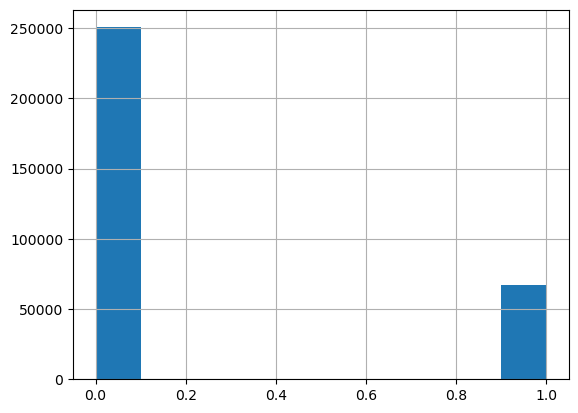

In [4]:
import matplotlib.pyplot as plt
df_Presence_Absence["Presence_Absence"].hist()

In [5]:
import geopandas as gpd

df_gdf = gpd.GeoDataFrame(df_Presence_Absence, geometry=gpd.points_from_xy(df_Presence_Absence['longitude'], df_Presence_Absence['latitude']))

In [6]:
import AIedes.data_loader.classificator_data_loader
import importlib

from AIedes.data_loader.classificator_data_loader import normalize_temperature_df, normalize_precipitation_df

df_Presence_Absence = normalize_temperature_df(df_Presence_Absence)
df_Presence_Absence = normalize_precipitation_df(df_Presence_Absence)

temp_cols ['temp_Jan_C', 'temp_Feb_C', 'temp_Mar_C', 'temp_Apr_C', 'temp_May_C', 'temp_Jun_C', 'temp_Jul_C', 'temp_Aug_C', 'temp_Sep_C', 'temp_Oct_C', 'temp_Nov_C', 'temp_Dec_C']
Temperature columns normalized with mean and std.
precip_cols ['precip_Jan_mm', 'precip_Feb_mm', 'precip_Mar_mm', 'precip_Apr_mm', 'precip_May_mm', 'precip_Jun_mm', 'precip_Jul_mm', 'precip_Aug_mm', 'precip_Sep_mm', 'precip_Oct_mm', 'precip_Nov_mm', 'precip_Dec_mm']
Precipitation columns normalized with mean and std.


In [7]:
features = ['temp_Jan_C', 'temp_Feb_C', 'temp_Mar_C', 'temp_Apr_C', 
            'temp_May_C', 'temp_Jun_C', 'temp_Jul_C', 'temp_Aug_C', 
            'temp_Sep_C', 'temp_Oct_C', 'temp_Nov_C', 'temp_Dec_C', 'precip_Jan_mm',
            'precip_Feb_mm', 'precip_Mar_mm', 'precip_Apr_mm',
            'precip_May_mm', 'precip_Jun_mm', 'precip_Jul_mm', 'precip_Aug_mm',
            'precip_Sep_mm', 'precip_Oct_mm', 'precip_Nov_mm', 'precip_Dec_mm']
datas = {}
df_years = {}

data = df_Presence_Absence[features + ["Presence_Absence"]].to_numpy()


In [8]:
import importlib
import torch
# set threads to 1 to avoid issues with multiprocessing in Jupyter notebooks
torch.set_num_threads(4)
# set number of cpu threads to 1 to avoid issues with multiprocessing in Jupyter notebooks
#torch.set_num_interop_threads(4)


In [9]:
import importlib
from locale import normalize
from AIedes.data_loader.classificator_data_loader import get_data_loaders
# Get data loaders and input size
batch_size = 1024
learning_rate = 0.002
random_seed = 42

train_loaders = {}
test_loaders = {}
train_loader_order, test_loader_order, input_size_order, _ = get_data_loaders(
    data=data, batch_size = batch_size, test_ratio = 1, random_seed = random_seed, shuffle = False, normalize=False
)



/home/biazzin/git/AIedes/src/AIedes/data_loader/classificator_data_loader.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.float)  # Labels for classification


# Function like the paper

In [10]:
import pandas as pd
import pickle
from AIedes.train.classificator_train    import run_model
from AIedes.evaluation.classificator_evaluate import evaluate_model_nuts3, evaluate_model


with open("../res/results_and_models_2020_[50, 50, 50]_temp_tp.pkl", "rb") as f:
    res_df = pickle.load(f)


In [11]:
import torch

def compute_suitability_index(model_, data_loader_):
    with torch.no_grad():
        res = []
        for data in data_loader_:
            inputs, labels = data
            outputs = torch.sigmoid(model_(inputs))
            res.append(outputs)
    return torch.cat(res)

In [12]:
import matplotlib.pyplot as plt
import geopandas as gpd

net_ = res_df.loc[0, 'model'][0]

# plot on maps the suitability index for each year
df_temp = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code", 'year']].copy()
df_temp["predicted_estim_risk"] = compute_suitability_index(net_, test_loader_order).numpy()
#df_temp = gpd.GeoDataFrame(df_temp, geometry=gpd.points_from_xy(df_Presence_Absence['longitude'], df_Presence_Absence['latitude']))
df_temp["predicted"] = df_temp["predicted_estim_risk"] > 0.5

#df_temp = df_temp.to_crs(epsg=3857)

In [13]:
df_temp

,Presence_Absence,geometry,NUTS3_Code,year,predicted_estim_risk,predicted
0,1,POINT (24.075498917146547 34.86250706680018),EL434,2020,0.378646,False
1,1,POINT (24.075498917146547 34.86250706680018),EL434,2020,0.378646,False
2,1,POINT (24.872258489881634 35.02397785812761),EL431,2020,1.000000,True
3,1,POINT (24.872258489881634 35.02397785812761),EL431,2020,1.000000,True
4,1,POINT (25.001106849999257 35.01369007622064),EL431,2020,1.000000,True
...,...,...,...,...,...,...
317587,0,POINT (27.83774666909342 70.92770631294475),NO074,2050,0.000000,False
317588,0,POINT (28.14988434286015 70.9129234272953),NO074,2050,0.000000,False
317589,0,POINT (28.14988434286015 70.9129234272953),NO074,2050,0.000000,False
317590,0,POINT (27.885532492396514 71.03659858406702),NO074,2050,0.000000,False


In [14]:
import geopandas as gpd
from shapely import wkt

df_temp['geometry'] = df_temp['geometry'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df_temp, geometry='geometry', crs='EPSG:4326')


In [15]:
gdf.columns

Index(['Presence_Absence', 'geometry', 'NUTS3_Code', 'year',
       'predicted_estim_risk', 'predicted'],
      dtype='object')

In [16]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import wkt

# 1) Convert your DataFrame into a GeoDataFrame with real geometry
gdf = gdf.copy()  # Use the year you want

# 2) Extract latitudes and longitudes
#    (Note: shapely Point.x = lon, Point.y = lat)
lats = np.array([pt.y for pt in gdf.geometry])
lons = np.array([pt.x for pt in gdf.geometry])

dlat = 0.11
dlon = 0.11

print(f"Grid spacing: Δlat = {dlat:.6f}°, Δlon = {dlon:.6f}°")

# 4) Define the area function
def grid_cell_area(lat_deg, dlat_deg, dlon_deg, radius=6_371_000):
    """
    Compute the surface area of a grid cell on a spherical Earth.
    Returns area in m².
    """
    lat = np.deg2rad(lat_deg)
    dlat = np.deg2rad(dlat_deg)
    dlon = np.deg2rad(dlon_deg)
    lat1 = lat - dlat/2
    lat2 = lat + dlat/2
    return radius**2 * dlon * (np.sin(lat2) - np.sin(lat1))

# 5) Apply it to every point
gdf['cell_area_m2'] = grid_cell_area(
    lat_deg = lats,
    dlat_deg = dlat,
    dlon_deg = dlon
)

# Now you have a 'cell_area_m2' column.  
# For example, total area for risk > 0.5 is:
total_high_risk_area_km2 = gdf.loc[gdf['predicted_estim_risk'] > 0.5, 'cell_area_m2'].sum() / 1e6
print(f"High-risk area (>0.5): {total_high_risk_area_km2:.2f} km²")


Grid spacing: Δlat = 0.110000°, Δlon = 0.110000°
High-risk area (>0.5): 8933161.46 km²


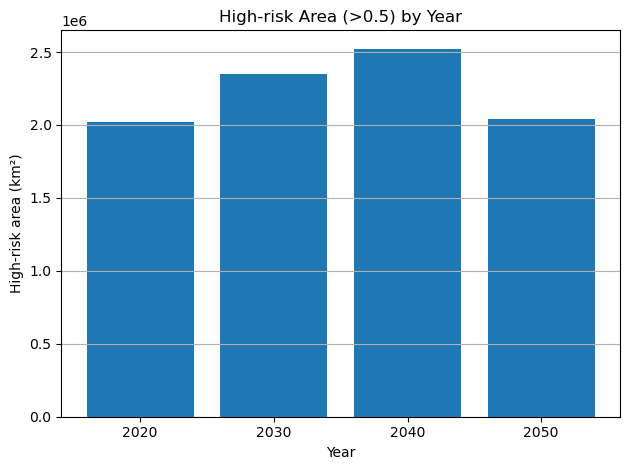

In [17]:
import matplotlib.pyplot as plt

# Compute high-risk area (km²) per year
years = sorted(gdf['year'].unique())
area_by_year = [
    gdf.loc[
        (gdf['year'] == year) & (gdf['predicted_estim_risk'] > 0.5),
        'cell_area_m2'
    ].sum() / 1e6
    for year in years
]

# Plot
plt.figure()
plt.bar(years, area_by_year)
plt.xlabel('Year')
plt.ylabel('High-risk area (km²)')
plt.title('High-risk Area (>0.5) by Year')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


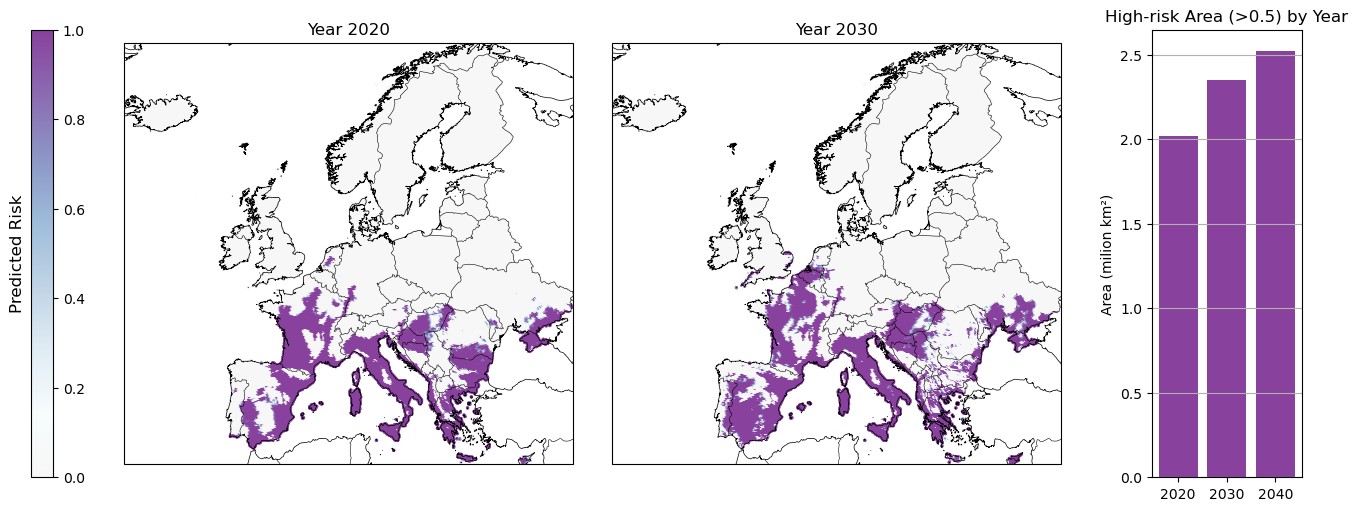

In [18]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely import wkt
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib as mpl

# Suppose df_temp is already loaded
df = gpd.GeoDataFrame(df_temp.copy(), geometry='geometry', crs='EPSG:4326')

fig = plt.figure(figsize=(13, 5), constrained_layout=True)
#fig.suptitle('Predicted Risk Areas for Aedes Albopictus', fontsize=16, fontweight='bold')

# Prepare gridspec: 4 columns (2 maps, 1 colorbar, 1 barplot)
gs = fig.add_gridspec(1, 4, width_ratios=[0.15, 3, 3, 1], wspace=0.12)
years = sorted(df['year'].unique())[0:2]
minx, miny, maxx, maxy = df.total_bounds

axes = [fig.add_subplot(gs[0, 1+i], projection=ccrs.PlateCarree()) for i in range(len(years))]
ax_cbar = fig.add_subplot(gs[0, 0])  # dedicated colorbar axis

# Find global min/max for colormap normalization
vmin = df['predicted_estim_risk'].min()
vmax = df['predicted_estim_risk'].max()

# Define your color list (white, pink, red)
colors = ['#ffffff', '#ffb6c1', '#ff0000']
colors = ['#ffffcc','#ffeda0','#fed976','#feb24c','#fd8d3c','#fc4e2a','#e31a1c']
colors = ['#f7f7f7','#f7fcfd','#e0ecf4','#bfd3e6','#9ebcda','#8c96c6','#8c6bb1','#88419d']
# Create the colormap
custom_cmap = mpl.colors.LinearSegmentedColormap.from_list('my_reds', colors)

cmap = custom_cmap
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

for i, year in enumerate(years):
    ax = axes[i]
    df_year = df[df['year'] == year]
    ax.set_title(f'Year {year}', fontsize=12)
    ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor='white')
    df_year.plot(
        column='predicted_estim_risk',
        cmap=cmap,
        ax=ax,
        markersize=2,
        legend=False,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax
    )

# Make ScalarMappable for colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm._A = []  # this is a matplotlib quirk

# Plot colorbar vertically, shrink as needed
cbar = plt.colorbar(sm, cax=ax_cbar, orientation='vertical')
cbar.set_label('Predicted Risk', fontsize=12)
ax_cbar.yaxis.set_label_position('left')

# Bar plot (unchanged)

# Bar plot (unchanged)
years_all = sorted(df['year'].unique())[0:3]

risk_area_km2 = [
    gdf.loc[
        (df['year'] == yr) & (df['predicted_estim_risk'] > 0.5),
        'cell_area_m2'
    ].sum() / 1e6
    for yr in years_all
]
ax_bar = fig.add_subplot(gs[0, 3])
risk_area_km2 = [v/1e6 for v in risk_area_km2]
ax_bar.bar(years_all, risk_area_km2, color='#88419d')
ax_bar.set_ylabel('Area (milion km²)')
ax_bar.set_xticks(years_all)
ax_bar.set_title('High-risk Area (>0.5) by Year', fontsize=12)
ax_bar.grid(axis='y')
plt.savefig('../img/predicted_risk_aedes_albopictus.png', dpi=300, bbox_inches='tight')
plt.show()